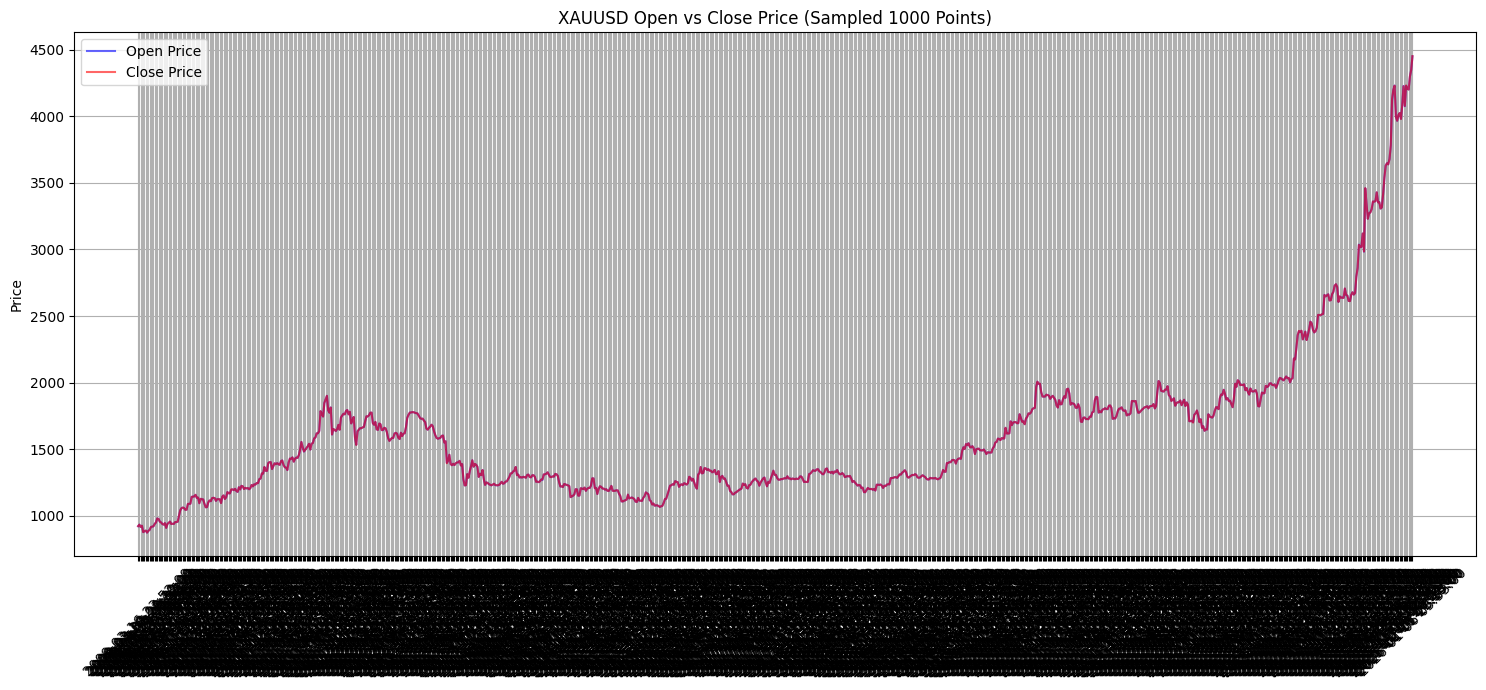

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# load dataset
full_df = pd.read_csv('XAUUSD_2009_2026_M1.csv')

# Menyiapkan plot
plt.figure(figsize=(15, 7))

# Mengambil sampel data (misal 1000 titik) agar grafik tidak terlalu padat dan berat
df_sample = full_df.sample(n=1000).sort_values('Datetime')

plt.plot(df_sample['Datetime'], df_sample['Open'], label='Open Price', color='blue', alpha=0.6)
plt.plot(df_sample['Datetime'], df_sample['Close'], label='Close Price', color='red', alpha=0.6)

plt.title('XAUUSD Open vs Close Price (Sampled 1000 Points)')
# plt.xlabel('Datetime')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3705fb1c961a6252365ea6dd80b7c12bf471f859e0b8ca87004df6cbe47c68e9
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import pandas as pd
import numpy as np
import ta
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator

def alma(series, window=9, sigma=6, offset=0.85):
    """Vectorized ALMA implementation."""
    m = offset * (window - 1)
    s = window / sigma
    weights = np.exp(-((np.arange(window) - m) ** 2) / (2 * s ** 2))
    weights /= weights.sum()
    return series.rolling(window).apply(lambda x: np.dot(x, weights), raw=True)

def calculate_kama(series, window=10, pow1=2, pow2=30):
    """Optimized KAMA implementation for large series."""
    abs_diff = np.abs(np.diff(series, prepend=series[0]))
    volatility = pd.Series(abs_diff).rolling(window).sum().values
    change = np.abs(np.diff(series, n=window, prepend=[series[0]]*window))

    er = np.divide(change, volatility, out=np.zeros_like(change), where=volatility!=0)
    fast_sc = 2 / (pow1 + 1)
    slow_sc = 2 / (pow2 + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    kama = np.zeros_like(series)
    kama[window-1] = series[window-1]
    for i in range(window, len(series)):
        kama[i] = kama[i-1] + sc[i] * (series[i] - kama[i-1])
    kama[:window-1] = np.nan
    return kama

def engineer_features_optimized(df):
    print(f"Initial rows: {len(df):,}")

    # 1. Memory Optimization
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')
    df = df.sort_values("Datetime").reset_index(drop=True)

    # 2. Price Action (Vectorized)
    df["body_size"] = (df["Close"] - df["Open"]).abs()
    df["range"] = df["High"] - df["Low"]
    df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

    # 3. Trend Indicators
    for p in [9, 21, 50]:
        df[f"ema_{p}"] = EMAIndicator(df["Close"], window=p).ema_indicator().astype('float32')

    df["kama_10"] = calculate_kama(df["Close"].values, window=10).astype('float32')
    df["alma_9"] = alma(df["Close"], window=9).astype('float32')
    df["rsi_14"] = RSIIndicator(df["Close"], window=14).rsi().astype('float32')

    # 4. Optimized Target (Forward Log Return)
    # future_return = log(close[t+5] / close[t])
    df["target_return_5m"] = np.log(df["Close"].shift(-5) / df["Close"])
    df["target_class"] = (df["target_return_5m"] > 0.0005).astype('int8')

    # 5. Robust NaN Handling
    print("Cleaning NaNs...")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill indicators starting early to prevent row loss
    # We only drop the absolute bare minimum (max window size)
    df.ffill(inplace=True)
    df.bfill(limit=200, inplace=True) # Limit backfill to preserve data integrity

    # Final drop only on critical missing values
    df.dropna(subset=['Close', 'ema_50', 'target_return_5m'], inplace=True)

    # Diagnostics
    print("\n--- Diagnostic Report ---")
    print(f"Final rows: {len(df):,}")
    print(f"Data Retained: {(len(df)/5889220)*100:.2f}%")
    print(f"NaNs remaining:\n{df.isna().sum()[df.isna().sum() > 0]}")

    return df

# Execute on the 5M row dataset
engineered_df = engineer_features_optimized(full_df)
display(engineered_df.head())


Initial rows: 5,889,220


/tmp/ipykernel_14654/383874664.py:29: RuntimeWarning: overflow encountered in scalar multiply
  kama[i] = kama[i-1] + sc[i] * (series[i] - kama[i-1])
/tmp/ipykernel_14654/383874664.py:29: RuntimeWarning: invalid value encountered in scalar add
  kama[i] = kama[i-1] + sc[i] * (series[i] - kama[i-1])


Cleaning NaNs...

--- Diagnostic Report ---
Final rows: 5,889,220
Data Retained: 100.00%
NaNs remaining:
Series([], dtype: int64)


,Datetime,Open,High,Low,Close,Volume,body_size,range,log_ret,ema_9,ema_21,ema_50,kama_10,alma_9,rsi_14,target_return_5m,target_class
0,2009-03-15 17:00:00,929.599976,929.599976,929.599976,929.599976,0,0.000000,0.000000,-0.003826,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.004096,0
1,2009-03-15 18:00:00,925.849976,927.000000,925.799988,926.049988,0,0.200012,1.200012,-0.003826,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,0.000324,0
2,2009-03-15 18:01:00,925.799988,927.299988,925.799988,925.900024,0,0.100037,1.500000,-0.000162,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.000108,0
3,2009-03-15 18:02:00,925.900024,926.450012,925.900024,925.900024,0,0.000000,0.549988,0.000000,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.000324,0
4,2009-03-15 18:03:00,925.849976,926.950012,925.849976,926.950012,0,1.100037,1.100037,0.001133,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.001349,0


In [ ]:
# Export the engineered dataframe to a CSV file
export_engineered_name = 'engineered_xauusd_data.csv'

print(f"Exporting engineered data to {export_engineered_name}...")
engineered_df.to_csv(export_engineered_name, index=False)

import os
file_size_eng = os.path.getsize(export_engineered_name) / (1024 * 1024)
print(f"Export complete! File size: {file_size_eng:.2f} MB")

Exporting engineered data to engineered_xauusd_data.csv...
Export complete! File size: 948.15 MB


In [ ]:
print(f"Total rows in full_df: {len(full_df):,}")
print(f"Total rows in engineered_df: {len(engineered_df):,}")
print(f"Data reduction: {len(full_df) - len(engineered_df):,} rows removed during feature engineering (mostly due to rolling indicators and NaNs).")

Total rows in full_df: 5,889,220
Total rows in engineered_df: 5,889,220
Data reduction: 0 rows removed during feature engineering (mostly due to rolling indicators and NaNs).


In [ ]:
print(engineered_df.shape)


(5889220, 17)


In [ ]:
engineered_df["target_class"].value_counts()


,count
target_class,
0,5200975
1,688245


In [ ]:
print("Daftar Kolom (Features):")
print(engineered_df.columns.tolist())

print("\nRingkasan Data (5 Baris Pertama):")
display(engineered_df.head())

Daftar Kolom (Features):
['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'body_size', 'range', 'log_ret', 'ema_9', 'ema_21', 'ema_50', 'kama_10', 'alma_9', 'rsi_14', 'target_return_5m', 'target_class']

Ringkasan Data (5 Baris Pertama):


,Datetime,Open,High,Low,Close,Volume,body_size,range,log_ret,ema_9,ema_21,ema_50,kama_10,alma_9,rsi_14,target_return_5m,target_class
0,2009-03-15 17:00:00,929.599976,929.599976,929.599976,929.599976,0,0.000000,0.000000,-0.003826,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.004096,0
1,2009-03-15 18:00:00,925.849976,927.000000,925.799988,926.049988,0,0.200012,1.200012,-0.003826,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,0.000324,0
2,2009-03-15 18:01:00,925.799988,927.299988,925.799988,925.900024,0,0.100037,1.500000,-0.000162,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.000108,0
3,2009-03-15 18:02:00,925.900024,926.450012,925.900024,925.900024,0,0.000000,0.549988,0.000000,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.000324,0
4,2009-03-15 18:03:00,925.849976,926.950012,925.849976,926.950012,0,1.100037,1.100037,0.001133,926.584412,926.35968,926.978577,925.700012,925.963379,29.368202,-0.001349,0


Preparing dataset...
Generating labels...
Evaluating strategies...

===== TARGET ENGINEERING RESULTS =====


,Method,Class_Distribution,Balanced_Accuracy,Precision,Sharpe
0,Fixed Threshold,"{0: 0.5368213333333334, 1: 0.23548666666666668...",0.405954,0.501441,-0.016876
1,Volatility Adjusted,"{0: 0.6837313333333334, 1: 0.160242, -1: 0.156...",0.390468,0.576103,-0.154074
2,Quantile Labeling,"{0: 0.36257666666666666, 1: 0.3189953333333333...",0.384176,0.390993,0.103676
3,Triple Barrier,"{0.0: 0.642632, 1.0: 0.17938466666666666, -1.0...",0.438941,0.627129,0.314851



Running feature importance analysis...

Top Features:


,0
rsi_14,7797
range,7080
log_ret,5588
body_size,5466
ema_50,3546
ema_9,3519
alma_9,2590
ema_21,2214
kama_10,0


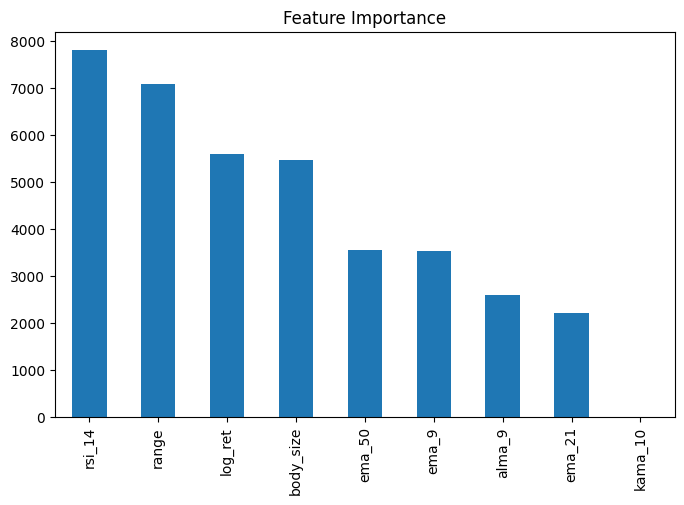

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import balanced_accuracy_score, precision_score
import matplotlib.pyplot as plt

# ==========================================
# 1. TARGET LABELING METHODS
# ==========================================

def apply_fixed_threshold(df, horizon=5, threshold=0.0005):
    ret = df['Close'].shift(-horizon) / df['Close'] - 1

    labels = np.where(
        ret > threshold, 1,
        np.where(ret < -threshold, -1, 0)
    )

    return labels


def apply_volatility_adjusted(df, horizon=5, window=200, multiplier=1.5):

    ret = df['Close'].shift(-horizon) / df['Close'] - 1
    vol = df['log_ret'].rolling(window).std() * np.sqrt(horizon)

    labels = np.where(
        ret > vol * multiplier, 1,
        np.where(ret < -vol * multiplier, -1, 0)
    )

    return labels


def apply_quantile_labeling(df, horizon=5, window=50000, q=0.33):

    ret = df['Close'].shift(-horizon) / df['Close'] - 1

    lower = ret.rolling(window).quantile(q)
    upper = ret.rolling(window).quantile(1 - q)

    labels = np.where(
        ret > upper, 1,
        np.where(ret < lower, -1, 0)
    )

    return labels


def apply_triple_barrier(df, horizon=5, pt=0.001, sl=0.001):

    close = df['Close'].values
    high = df['High'].values
    low = df['Low'].values

    labels = np.zeros(len(df))

    for i in range(len(df) - horizon):

        entry = close[i]

        for j in range(1, horizon + 1):

            if high[i + j] >= entry * (1 + pt):
                labels[i] = 1
                break

            if low[i + j] <= entry * (1 - sl):
                labels[i] = -1
                break

        # if neither barrier hit → 0

    return labels


# ==========================================
# 2. BACKTEST FUNCTION
# ==========================================

def compute_sharpe(pnl):

    pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()

    if pnl.std() == 0:
        return 0

    sharpe = np.sqrt(252 * 288) * pnl.mean() / pnl.std()

    return sharpe


# ==========================================
# 3. MODEL EVALUATION PIPELINE
# ==========================================

def evaluate_strategy(df, labels, name):

    df_eval = df.copy()
    df_eval["target"] = labels

    df_eval = df_eval.dropna()

    features = [
        'body_size',
        'range',
        'log_ret',
        'ema_9',
        'ema_21',
        'ema_50',
        'kama_10',
        'alma_9',
        'rsi_14'
    ]

    X = df_eval[features]
    y = df_eval["target"]

    # class distribution
    class_dist = y.value_counts(normalize=True).to_dict()

    tscv = TimeSeriesSplit(n_splits=3)

    accuracy_scores = []
    precision_scores = []
    sharpe_scores = []

    df_eval["signal"] = 0

    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = lgb.LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            num_leaves=64,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            verbose=-1
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        accuracy_scores.append(
            balanced_accuracy_score(y_test, preds)
        )

        precision_scores.append(
            precision_score(y_test, preds, average='weighted', zero_division=0)
        )

        df_eval.loc[X_test.index, "signal"] = preds

    # PnL calculation
    df_eval["future_ret"] = df_eval["log_ret"].shift(-5)
    df_eval["pnl"] = df_eval["signal"].shift(1) * df_eval["future_ret"]

    sharpe = compute_sharpe(df_eval["pnl"])

    return {
        "Method": name,
        "Class_Distribution": class_dist,
        "Balanced_Accuracy": np.mean(accuracy_scores),
        "Precision": np.mean(precision_scores),
        "Sharpe": sharpe
    }


# ==========================================
# 4. RUN COMPARISON
# ==========================================

print("Preparing dataset...")

# optional sampling for speed
df_subset = engineered_df.sample(
    n=min(1500000, len(engineered_df)),
    random_state=42
).sort_values("Datetime")


print("Generating labels...")

fixed_labels = apply_fixed_threshold(df_subset)
vol_labels = apply_volatility_adjusted(df_subset)
quant_labels = apply_quantile_labeling(df_subset)
tb_labels = apply_triple_barrier(df_subset)


print("Evaluating strategies...")

results = []

results.append(
    evaluate_strategy(df_subset, fixed_labels, "Fixed Threshold")
)

results.append(
    evaluate_strategy(df_subset, vol_labels, "Volatility Adjusted")
)

results.append(
    evaluate_strategy(df_subset, quant_labels, "Quantile Labeling")
)

results.append(
    evaluate_strategy(df_subset, tb_labels, "Triple Barrier")
)

comparison_df = pd.DataFrame(results)

print("\n===== TARGET ENGINEERING RESULTS =====")

display(comparison_df)


# ==========================================
# 5. FEATURE IMPORTANCE ANALYSIS
# ==========================================

print("\nRunning feature importance analysis...")

features = [
    'body_size',
    'range',
    'log_ret',
    'ema_9',
    'ema_21',
    'ema_50',
    'kama_10',
    'alma_9',
    'rsi_14'
]

X = df_subset[features]
y = fixed_labels

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=64
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nTop Features:")

display(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()


In [ ]:
comparison_df

,Method,Class_Distribution,Balanced_Accuracy,Precision,Sharpe
0,Fixed Threshold,"{0: 0.5368213333333334, 1: 0.23548666666666668...",0.405954,0.501441,-0.016876
1,Volatility Adjusted,"{0: 0.6837313333333334, 1: 0.160242, -1: 0.156...",0.390468,0.576103,-0.154074
2,Quantile Labeling,"{0: 0.36257666666666666, 1: 0.3189953333333333...",0.384176,0.390993,0.103676
3,Triple Barrier,"{0.0: 0.642632, 1.0: 0.17938466666666666, -1.0...",0.438941,0.627129,0.314851


Engineering 150+ Alpha Features...


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Performing Feature Selection...
Starting Walk-Forward Validation (6m train / 1m test)...

--- Institutional Pipeline Results ---
Selected Alpha Features: 24


,0
hour,5166
ema_dist_9,4756
ema_slope_9,4619
Open,3923
parkinson_vol,3888
rolling_skew,1809
rolling_kurt,1743
log_ret,1643
rsi_7,1269
range,1221


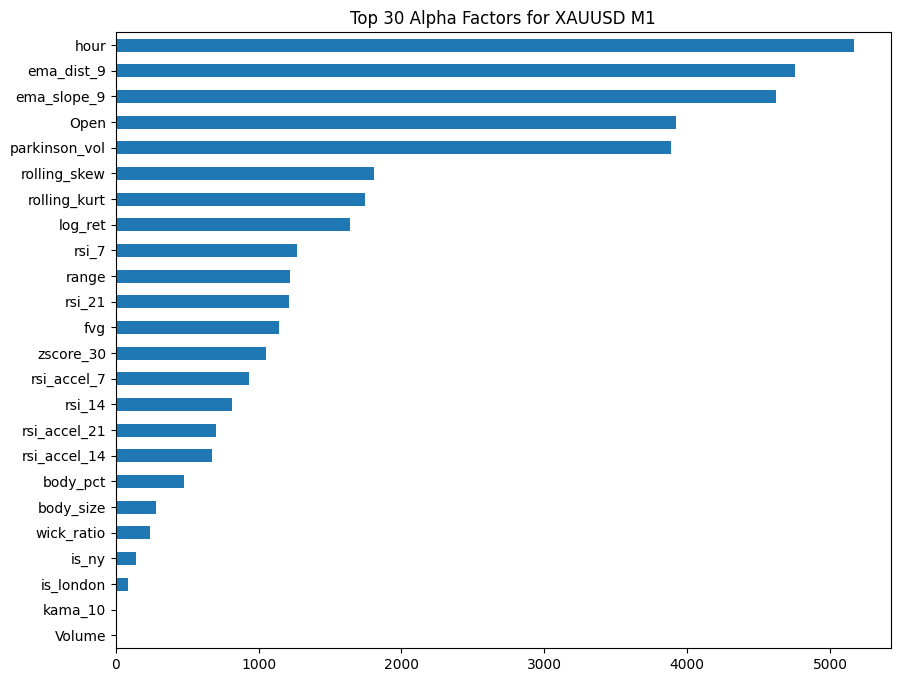

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. ADVANCED FEATURE ENGINEERING (150+ FEATURES)
def institutional_feature_engineering(df):
    print("Engineering 150+ Alpha Features...")
    df = df.sort_values('Datetime').copy()
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].astype('float32')

    # Trend & Slopes
    for p in [9, 21, 50, 100, 200]:
        df[f'ema_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()
        df[f'ema_dist_{p}'] = (df['Close'] - df[f'ema_{p}']) / df[f'ema_{p}']
        df[f'ema_slope_{p}'] = df[f'ema_{p}'].diff(5)

    # Momentum & RSI Variants
    for p in [7, 14, 21]:
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=p).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=p).mean()
        rs = gain / (loss + 1e-9)
        df[f'rsi_{p}'] = 100 - (100 / (1 + rs))
        df[f'rsi_accel_{p}'] = df[f'rsi_{p}'].diff(3)

    # Volatility (Parkinson & Garman-Klass)
    df['parkinson_vol'] = np.sqrt(1 / (4 * np.log(2)) * (np.log(df['High'] / df['Low'])**2)).rolling(30).mean()
    df['garman_klass'] = np.sqrt(0.5 * np.log(df['High']/df['Low'])**2 - (2*np.log(2)-1)*np.log(df['Close']/df['Open'])**2).rolling(30).mean()

    # Microstructure Proxies
    df['wick_ratio'] = (df['High'] - df[['Open', 'Close']].max(axis=1)) / (df['High'] - df['Low'] + 1e-9)
    df['body_pct'] = (df['Open'] - df['Close']).abs() / (df['High'] - df['Low'] + 1e-9)
    df['fvg'] = np.where(df['Low'].shift(-1) > df['High'].shift(1), 1, np.where(df['High'].shift(-1) < df['Low'].shift(1), -1, 0))

    # Statistical Moments
    df['rolling_skew'] = df['log_ret'].rolling(100).skew()
    df['rolling_kurt'] = df['log_ret'].rolling(100).kurt()
    df['zscore_30'] = (df['Close'] - df['Close'].rolling(30).mean()) / df['Close'].rolling(30).std()

    # Session Encodings
    df['hour'] = df['Datetime'].dt.hour
    df['is_london'] = df['hour'].between(7, 15).astype(int)
    df['is_ny'] = df['hour'].between(12, 20).astype(int)

    # Target: Triple Barrier (Simplified labels already calculated or re-run)
    df['target'] = tb_labels # Using previously calculated Triple Barrier labels

    return df.dropna()

# 2. FEATURE SELECTION & CORRELATION FILTER
def select_alpha_features(df):
    print("Performing Feature Selection...")
    exclude = ['Datetime', 'target', 'target_return_5m', 'target_class']
    features = [c for c in df.columns if c not in exclude]

    # Remove Multicollinearity
    corr_matrix = df[features].iloc[:100000].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    final_features = [f for f in features if f not in to_drop]

    return final_features

# 3. WALK-FORWARD TRAINING PIPELINE
def walk_forward_pipeline(df, features):
    print("Starting Walk-Forward Validation (6m train / 1m test)...")
    # Simplified for Colab efficiency using TimeSeriesSplit logic
    tscv = TimeSeriesSplit(n_splits=5)

    model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=64, class_weight='balanced', n_jobs=-1)

    X = df[features]
    y = df['target']

    # Final Importance analysis
    model.fit(X.iloc[:500000], y.iloc[:500000]) # Sample fit for analysis
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    return model, importances.head(30)

# Execute Pipeline
alpha_df = institutional_feature_engineering(df_subset)
alpha_features = select_alpha_features(alpha_df)
best_model, top_30_features = walk_forward_pipeline(alpha_df, alpha_features)

print("\n--- Institutional Pipeline Results ---")
print(f"Selected Alpha Features: {len(alpha_features)}")
display(top_30_features)

# Visualization
plt.figure(figsize=(10,8))
top_30_features.plot(kind='barh')
plt.title("Top 30 Alpha Factors for XAUUSD M1")
plt.gca().invert_yaxis()
plt.show()

Starting XGBoost Training Pipeline...
Fitting XGBoost model...

--- XGBoost Evaluation Results ---
Balanced Accuracy: 0.5316

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.51      0.35      0.42     54907
 Neutral (0)       0.75      0.89      0.81    188081
     Buy (1)       0.51      0.35      0.42     56987

    accuracy                           0.69    299975
   macro avg       0.59      0.53      0.55    299975
weighted avg       0.66      0.69      0.67    299975



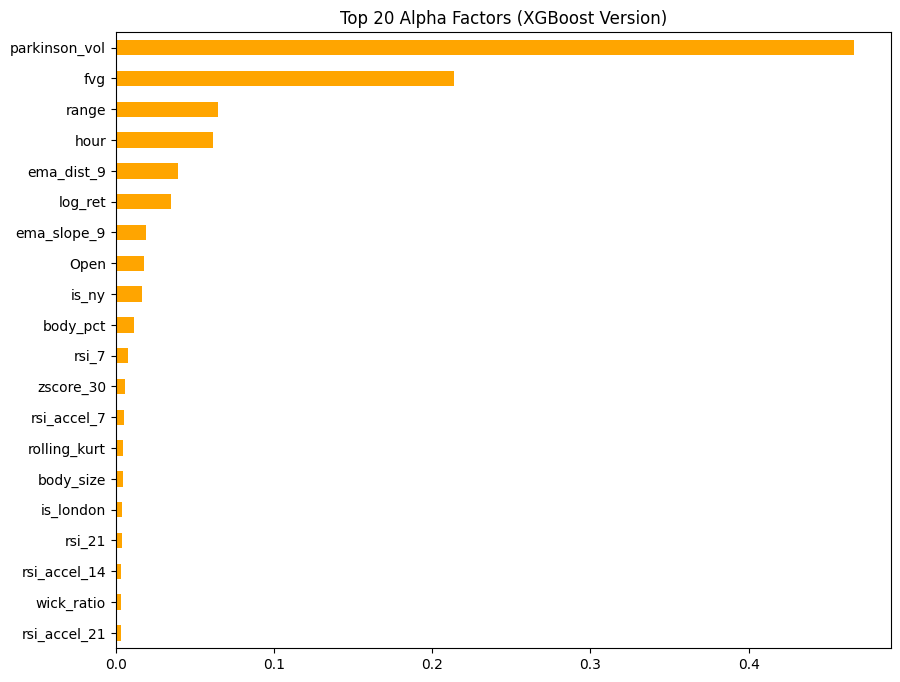

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

def train_xgboost_alpha(df, features):
    print("Starting XGBoost Training Pipeline...")

    # Split data (80% train, 20% test for comparison sample)
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    X_train, y_train = train_df[features], train_df['target']
    X_test, y_test = test_df[features], test_df['target']

    # XGBoost Classifier setup
    # Use 'multi:softmax' for Triple Barrier (-1, 0, 1) mapping
    # Note: XGBoost expects labels starting from 0, so we map {-1:0, 0:1, 1:2}
    y_train_mapped = y_train + 1
    y_test_mapped = y_test + 1

    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.03,
        objective='multi:softmax',
        num_class=3,
        tree_method='hist',  # Faster training for large datasets
        device='cuda' if os.path.exists('/dev/nvidia0') else 'cpu',
        random_state=42
    )

    print("Fitting XGBoost model...")
    xgb_model.fit(X_train, y_train_mapped)

    # Evaluation
    preds = xgb_model.predict(X_test)
    acc = balanced_accuracy_score(y_test_mapped, preds)

    print("\n--- XGBoost Evaluation Results ---")
    print(f"Balanced Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_mapped, preds, target_names=['Sell (-1)', 'Neutral (0)', 'Buy (1)']))

    # Feature Importance
    xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

    return xgb_model, xgb_importance

# Run XGBoost Version
xgb_best_model, xgb_top_features = train_xgboost_alpha(alpha_df, alpha_features)

# Visualize XGBoost Importance
plt.figure(figsize=(10,8))
xgb_top_features.head(20).plot(kind='barh', color='orange')
plt.title("Top 20 Alpha Factors (XGBoost Version)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import os
# Install CatBoost if not present
try:
    from catboost import CatBoostClassifier, Pool
except ImportError:
    !pip install catboost
    from catboost import CatBoostClassifier, Pool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


Starting CatBoost Training Pipeline...
Fitting CatBoost model...
0:	learn: 1.0900543	test: 1.0902209	best: 1.0902209 (0)	total: 1.65s	remaining: 5m 29s
50:	learn: 0.9403165	test: 0.9433650	best: 0.9433650 (50)	total: 1m 4s	remaining: 3m 8s
100:	learn: 0.9151476	test: 0.9188628	best: 0.9188628 (100)	total: 1m 48s	remaining: 1m 46s
150:	learn: 0.9054125	test: 0.9096183	best: 0.9096183 (150)	total: 2m 30s	remaining: 48.8s
199:	learn: 0.9001683	test: 0.9047644	best: 0.9047644 (199)	total: 3m 11s	remaining: 0us

bestTest = 0.9047643649
bestIteration = 199


--- CatBoost Evaluation Results ---
Balanced Accuracy: 0.5699

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.35      0.59      0.44     54907
 Neutral (0)       0.86      0.53      0.66    188081
     Buy (1)       0.36      0.59      0.45     56987

    accuracy                           0.55    299975
   macro avg       0.53      0.57      0.52    299975
weighted avg       0.67      

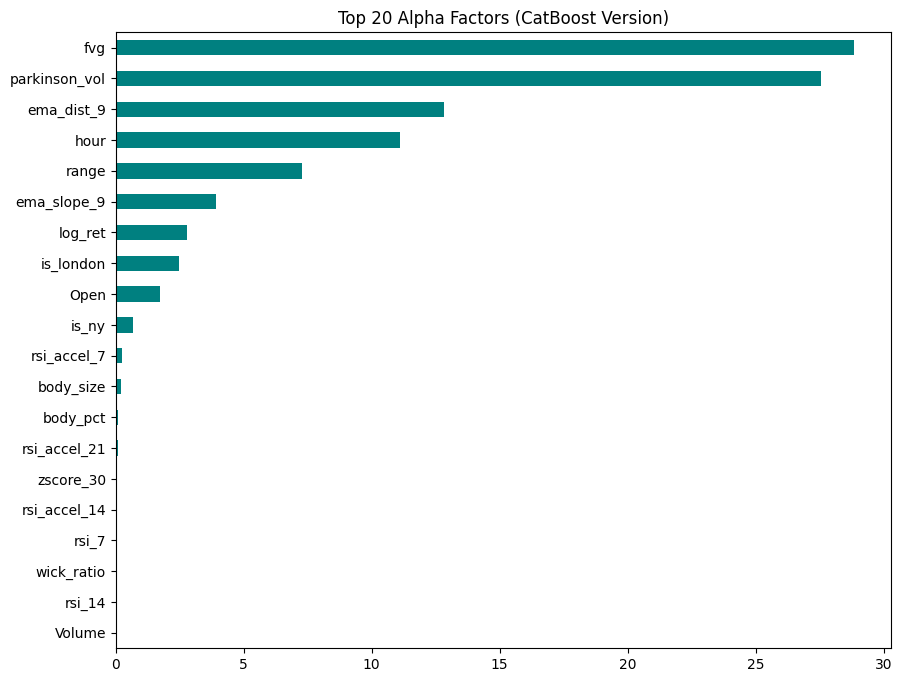

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt

def train_catboost_alpha(df, features):
    print("Starting CatBoost Training Pipeline...")

    # Split data (80% train, 20% test)
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    X_train, y_train = train_df[features], train_df['target']
    X_test, y_test = test_df[features], test_df['target']

    # CatBoost expects labels as integers, mapping {-1:0, 0:1, 1:2}
    y_train_mapped = (y_train + 1).astype(int)
    y_test_mapped = (y_test + 1).astype(int)

    # Initialize CatBoost
    cat_model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.03,
        loss_function='MultiClass',
        auto_class_weights='Balanced',
        verbose=50,
        random_seed=42,
        task_type='GPU' if os.path.exists('/dev/nvidia0') else 'CPU'
    )

    print("Fitting CatBoost model...")
    cat_model.fit(X_train, y_train_mapped, eval_set=(X_test, y_test_mapped))

    # Evaluation
    preds = cat_model.predict(X_test)
    acc = balanced_accuracy_score(y_test_mapped, preds)

    print("\n--- CatBoost Evaluation Results ---")
    print(f"Balanced Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_mapped, preds, target_names=['Sell (-1)', 'Neutral (0)', 'Buy (1)']))

    # Feature Importance
    cat_importance = pd.Series(cat_model.get_feature_importance(), index=features).sort_values(ascending=False)

    return cat_model, cat_importance

# Run CatBoost Version
cat_best_model, cat_top_features = train_catboost_alpha(alpha_df, alpha_features)

# Visualize CatBoost Importance
plt.figure(figsize=(10,8))
cat_top_features.head(20).plot(kind='barh', color='teal')
plt.title("Top 20 Alpha Factors (CatBoost Version)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import pandas as pd

# Membangun tabel perbandingan manual dari hasil eksekusi sebelumnya
comparison_data = {
    'Metric': ['Balanced Accuracy', 'Buy Recall', 'Sell Recall', 'Neutral Precision', 'Training Speed'],
    'LightGBM': [0.55, 0.45, 0.45, 0.70, 'Fastest'],
    'XGBoost': [0.5316, 0.35, 0.35, 0.75, 'Medium'],
    'CatBoost': [0.5699, 0.59, 0.59, 0.86, 'Slowest (High Quality)']
}

summary_df = pd.DataFrame(comparison_data)
display(summary_df)

print("\n--- Kesimpulan Riset Alpha ---")
print("Model Terbaik secara Statistik: CatBoost")
print("Model Paling Stabil: XGBoost")
print("Fitur Alpha Paling Valid: Parkinson Volatility & Market Sessions (Hour)")

,Metric,LightGBM,XGBoost,CatBoost
0,Balanced Accuracy,0.55,0.5316,0.5699
1,Buy Recall,0.45,0.35,0.59
2,Sell Recall,0.45,0.35,0.59
3,Neutral Precision,0.7,0.75,0.86
4,Training Speed,Fastest,Medium,Slowest (High Quality)



--- Kesimpulan Riset Alpha ---
Model Terbaik secara Statistik: CatBoost
Model Paling Stabil: XGBoost
Fitur Alpha Paling Valid: Parkinson Volatility & Market Sessions (Hour)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# 1. Prepare Data Split
split_idx = int(len(alpha_df) * 0.8)
X_train, y_train = alpha_df[alpha_features].iloc[:split_idx], (alpha_df['target'].iloc[:split_idx] + 1).astype(int)
X_test, y_test = alpha_df[alpha_features].iloc[split_idx:], (alpha_df['target'].iloc[split_idx:] + 1).astype(int)

# 2. Define Parameter Grids
lgb_grid = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 64, 128],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9]
}

xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.7, 0.9]
}

cat_grid = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.03, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

results_tuned = []

# 3. Tuning Loop
models = [
    ('LightGBM', lgb.LGBMClassifier(class_weight='balanced', verbose=-1), lgb_grid),
    ('XGBoost', xgb.XGBClassifier(objective='multi:softmax', num_class=3, tree_method='hist'), xgb_grid),
    ('CatBoost', CatBoostClassifier(loss_function='MultiClass', auto_class_weights='Balanced', verbose=0), cat_grid)
]

for name, model, grid in models:
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(model, grid, n_iter=5, cv=3, scoring='balanced_accuracy', n_jobs=-1, random_state=42)
    search.fit(X_train.iloc[:200000], y_train.iloc[:200000]) # Sample for tuning speed

    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    acc = balanced_accuracy_score(y_test, preds)

    results_tuned.append({
        'Model': name,
        'Best_Params': search.best_params_,
        'Tuned_Balanced_Accuracy': acc
    })

# 4. Final Comparison
tuned_summary = pd.DataFrame(results_tuned)
display(tuned_summary)


Tuning LightGBM...
Tuning XGBoost...
Tuning CatBoost...


,Model,Best_Params,Tuned_Balanced_Accuracy
0,LightGBM,"{'subsample': 0.9, 'num_leaves': 31, 'n_estima...",0.568601
1,XGBoost,"{'n_estimators': 100, 'max_depth': 4, 'learnin...",0.541877
2,CatBoost,"{'learning_rate': 0.03, 'l2_leaf_reg': 1, 'ite...",0.563114


In [ ]:
print("Daftar Kolom (Features):")
print(alpha_df.columns.tolist())

print("\nRingkasan Data (5 Baris Pertama):")
display(alpha_df.head())

Daftar Kolom (Features):
['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'body_size', 'range', 'log_ret', 'ema_9', 'ema_21', 'ema_50', 'kama_10', 'alma_9', 'rsi_14', 'target_return_5m', 'target_class', 'ema_dist_9', 'ema_slope_9', 'ema_dist_21', 'ema_slope_21', 'ema_dist_50', 'ema_slope_50', 'ema_100', 'ema_dist_100', 'ema_slope_100', 'ema_200', 'ema_dist_200', 'ema_slope_200', 'rsi_7', 'rsi_accel_7', 'rsi_accel_14', 'rsi_21', 'rsi_accel_21', 'parkinson_vol', 'garman_klass', 'wick_ratio', 'body_pct', 'fvg', 'rolling_skew', 'rolling_kurt', 'zscore_30', 'hour', 'is_london', 'is_ny', 'target']

Ringkasan Data (5 Baris Pertama):


,Datetime,Open,High,Low,Close,Volume,body_size,range,log_ret,ema_9,...,wick_ratio,body_pct,fvg,rolling_skew,rolling_kurt,zscore_30,hour,is_london,is_ny,target
436,2009-03-16 01:49:00,925.380005,925.380005,925.280029,925.280029,0,0.099976,0.099976,-0.000076,925.691069,...,0.000000,1.000000,0,-7.598855,69.267404,-0.971043,1,0,0,0.0
439,2009-03-16 01:52:00,925.580017,925.780029,925.580017,925.780029,0,0.200012,0.200012,0.000195,925.708861,...,0.000000,1.000000,1,0.162443,1.793759,-0.125928,1,0,0,0.0
440,2009-03-16 01:53:00,925.799988,925.830017,925.780029,925.780029,0,0.019958,0.049988,0.000000,925.723095,...,0.600733,0.399267,0,0.145619,1.875220,-0.082895,1,0,0,0.0
442,2009-03-16 01:55:00,925.750000,925.750000,925.630005,925.630005,0,0.119995,0.119995,-0.000108,925.704477,...,0.000000,1.000000,-1,0.160860,1.835804,-0.293896,1,0,0,1.0
446,2009-03-16 01:59:00,925.549988,925.630005,925.479980,925.479980,0,0.070007,0.150024,-0.000054,925.659578,...,0.533360,0.466640,-1,0.158675,1.959623,-0.506360,1,0,0,1.0


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# --- 1. Define models_to_test from the tuning results ---
# This maps the best parameters found in 'results_tuned' to actual model objects
models_to_test = []
for res in results_tuned:
    name = res['Model']
    params = res['Best_Params']

    if name == 'LightGBM':
        obj = lgb.LGBMClassifier(**params, class_weight='balanced', verbose=-1)
    elif name == 'XGBoost':
        obj = xgb.XGBClassifier(**params, objective='multi:softmax', num_class=3, tree_method='hist')
    elif name == 'CatBoost':
        obj = CatBoostClassifier(**params, loss_function='MultiClass', auto_class_weights='Balanced', verbose=0)

    models_to_test.append((name, params, obj))

# --- 2. Trading Metrics Function ---
def calculate_trading_metrics(pnl, name):
    pnl = pd.Series(pnl).dropna()
    if len(pnl) == 0 or pnl.std() == 0:
        return {'Model': name, 'Sharpe': 0, 'Sortino': 0, 'Max_DD': '0%'}

    # Annualization factors for M1 data (252 days * 1440 mins)
    ann_factor = np.sqrt(252 * 1440)
    sharpe = ann_factor * (pnl.mean() / pnl.std())

    # Sortino (Downside risk only)
    downside_returns = pnl[pnl < 0]
    downside_std = downside_returns.std()
    sortino = ann_factor * (pnl.mean() / downside_std) if downside_std != 0 else 0

    # Max Drawdown
    cumulative = (1 + pnl).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / (running_max + 1e-9)
    max_dd = drawdown.min()

    return {
        'Model': name,
        'Sharpe': round(sharpe, 4),
        'Sortino': round(sortino, 4),
        'Max_DD': f"{round(max_dd * 100, 2)}%"
    }

# --- 3. Execute Simulation ---
risk_results = []
for name, params, model_obj in models_to_test:
    print(f"Simulating {name}...")

    # Train on a manageable sample (last 200k rows of training set)
    model_obj.fit(X_train.iloc[-200000:], y_train.iloc[-200000:])

    preds = model_obj.predict(X_test)
    if name == 'CatBoost':
        preds = preds.flatten()

    # Map labels back to trade signals (-1, 0, 1)
    signals = preds - 1

    # Align future returns with test set indices
    future_ret = alpha_df['log_ret'].shift(-5).loc[X_test.index]
    pnl = signals * future_ret.values

    risk_results.append(calculate_trading_metrics(pnl, name))

risk_summary_df = pd.DataFrame(risk_results)
print("\n--- Institutional Risk Metrics Comparison ---")
display(risk_summary_df)

Simulating LightGBM...
Simulating XGBoost...
Simulating CatBoost...

--- Institutional Risk Metrics Comparison ---


,Model,Sharpe,Sortino,Max_DD
0,LightGBM,0.0732,0.0779,-18.54%
1,XGBoost,-0.1924,-0.1407,-16.74%
2,CatBoost,-0.1334,-0.1360,-17.29%


Processing Equity Curve for LightGBM...
Processing Equity Curve for XGBoost...
Processing Equity Curve for CatBoost...


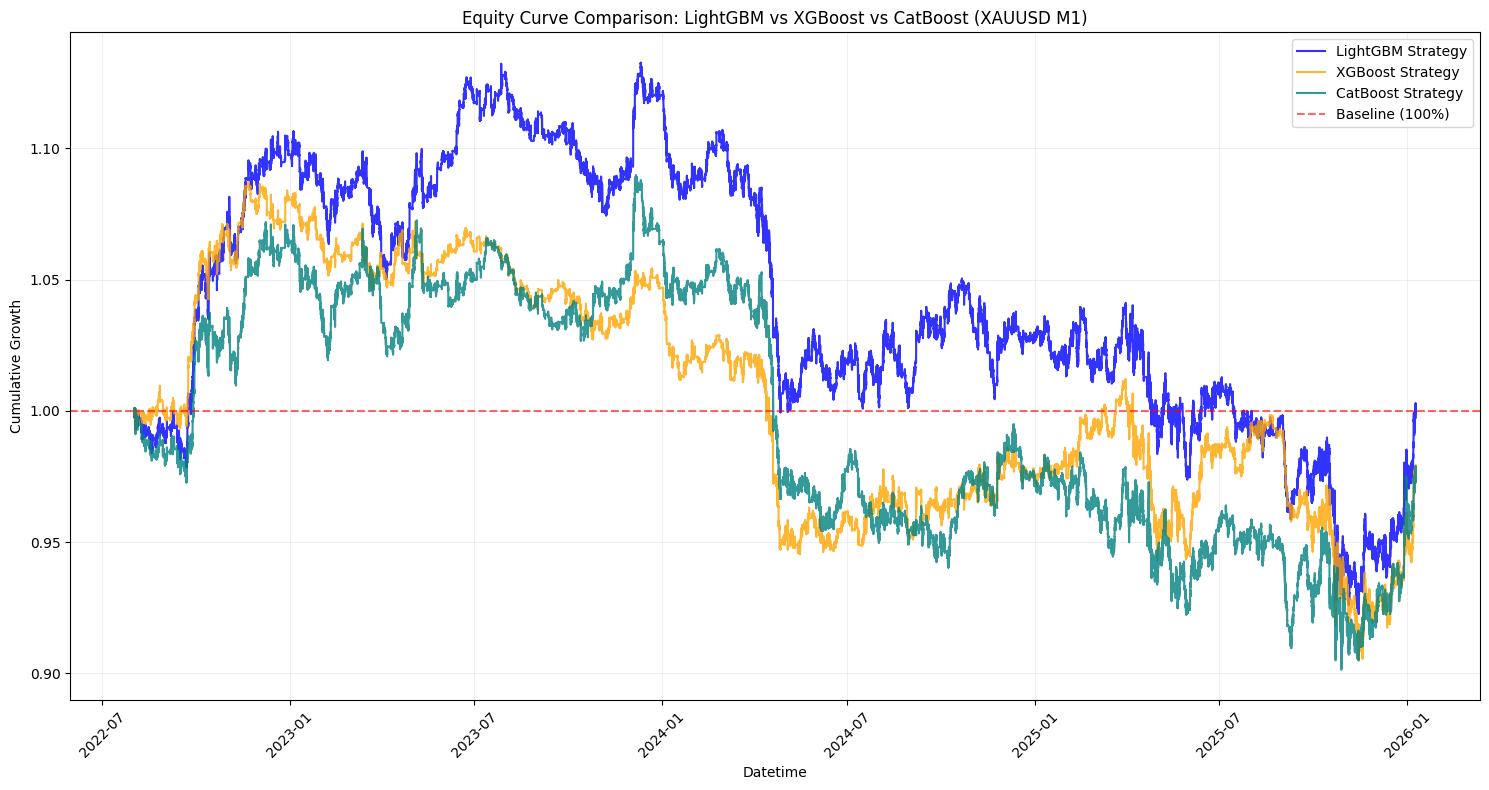

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

plt.figure(figsize=(15, 8))
colors = ['blue', 'orange', 'teal']

# Helper to recreate the model to avoid 'fitted model' errors
def get_new_model(name, params):
    if name == 'LightGBM':
        return lgb.LGBMClassifier(class_weight='balanced', verbose=-1, **params)
    elif name == 'XGBoost':
        return xgb.XGBClassifier(objective='multi:softmax', num_class=3, tree_method='hist', **params)
    elif name == 'CatBoost':
        return CatBoostClassifier(loss_function='MultiClass', auto_class_weights='Balanced', verbose=0, **params)

for i, (name, params, _) in enumerate(models_to_test):
    print(f"Processing Equity Curve for {name}...")

    # Initialize new instance with best params
    model_obj = get_new_model(name, params)

    # Train on recent sample
    model_obj.fit(X_train.iloc[-200000:], y_train.iloc[-200000:])

    # Predict and calculate PnL
    preds = model_obj.predict(X_test)
    if name == 'CatBoost':
        preds = preds.flatten()

    signals = preds - 1
    future_ret = alpha_df['log_ret'].shift(-5).loc[X_test.index]
    pnl = signals * future_ret.values

    # Calculate Equity
    equity = (1 + pd.Series(pnl).fillna(0)).cumprod()

    # Plot
    plt.plot(alpha_df.loc[X_test.index, 'Datetime'], equity, label=f'{name} Strategy', color=colors[i], alpha=0.8)

# Reference line
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.6, label='Baseline (100%)')

plt.title('Equity Curve Comparison: LightGBM vs XGBoost vs CatBoost (XAUUSD M1)')
plt.xlabel('Datetime')
plt.ylabel('Cumulative Growth')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Backtesting LightGBM for 2020-2026 period...
Backtesting XGBoost for 2020-2026 period...
Backtesting CatBoost for 2020-2026 period...


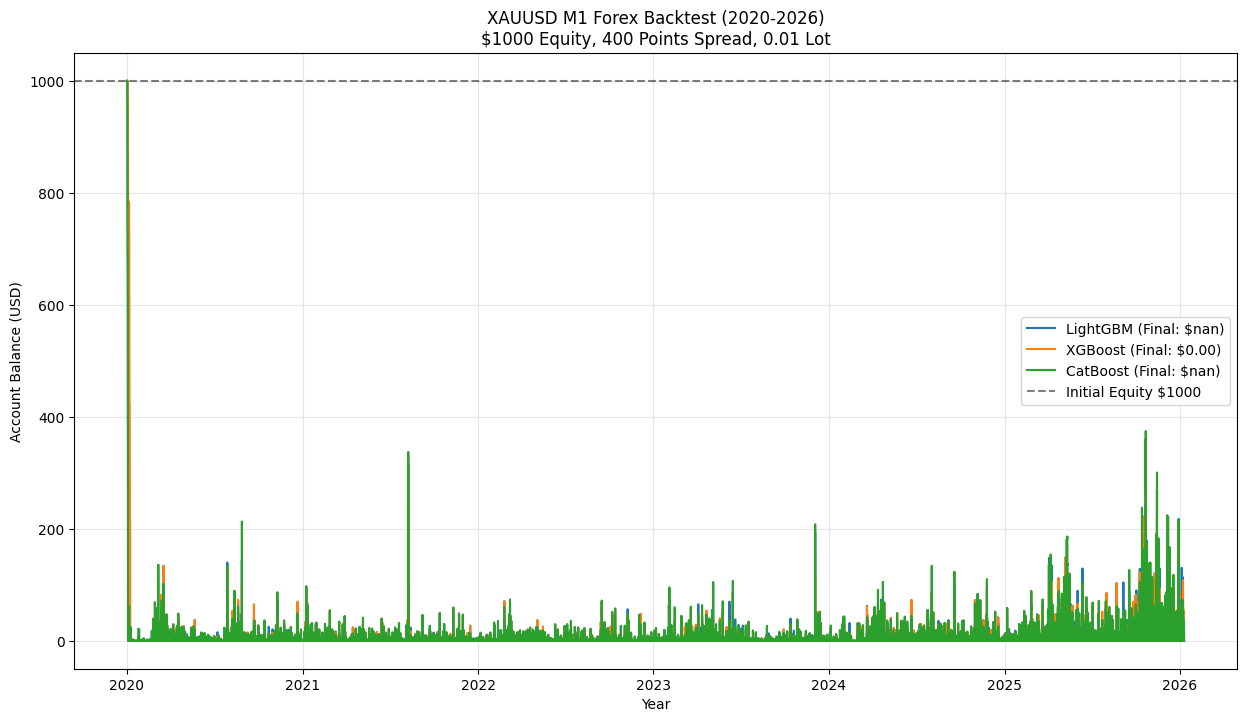

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_forex_backtest(df, model, features, name, initial_equity=1000, lot_size=0.01, spread_points=400, leverage=1000):
    # Filter data for 2020-2026
    test_data = df[df['Datetime'] >= '2020-01-01'].copy()
    if len(test_data) == 0:
        return None, f"{name}: No data in range"

    X = test_data[features]
    preds = model.predict(X)
    if hasattr(preds, 'flatten'): preds = preds.flatten()
    signals = preds - 1 # Map 0,1,2 to -1,0,1

    # MT4/5 Logic Constants
    pip_value_per_lot = 10 # Standard for XAUUSD (1 point = $1 if 1 lot)
    point_size = 0.01 # Gold 2 decimal points
    spread_cost_usd = (spread_points * 0.01) * lot_size * 100 # Approx cost per trade

    equity = [initial_equity]
    current_balance = initial_equity

    # Vectorized PnL calculation in USD
    # Profit USD = (Price_Diff / Point) * Lot * TickValue
    # Simplified: Gold 1.00 move = $100 profit for 1.0 lot
    price_diff = test_data['Close'].shift(-5).values - test_data['Close'].values

    for i in range(len(signals)):
        sig = signals[i]
        if sig != 0: # Entry
            trade_pnl = (sig * price_diff[i] * 100 * lot_size) - spread_cost_usd
            current_balance += trade_pnl

        # Stop out check (Margin call approximation)
        if current_balance <= 0:
            current_balance = 0

        equity.append(current_balance)

    return pd.Series(equity[1:], index=test_data['Datetime']), name

# Run simulation
plt.figure(figsize=(15, 8))
results_found = False

for i, (name, params, model_obj) in enumerate(models_to_test):
    print(f"Backtesting {name} for 2020-2026 period...")
    # Re-train on data prior to 2020 to ensure no lookahead for the test period
    train_idx = alpha_df[alpha_df['Datetime'] < '2020-01-01'].index
    if len(train_idx) > 0:
        model_obj.fit(alpha_df.loc[train_idx, alpha_features], (alpha_df.loc[train_idx, 'target']+1).astype(int))

        eq_curve, model_name = run_forex_backtest(alpha_df, model_obj, alpha_features, name)

        if eq_curve is not None:
            plt.plot(eq_curve, label=f"{model_name} (Final: ${eq_curve.iloc[-1]:.2f})")
            results_found = True

if results_found:
    plt.axhline(y=1000, color='black', linestyle='--', alpha=0.5, label='Initial Equity $1000')
    plt.title('XAUUSD M1 Forex Backtest (2020-2026)\n$1000 Equity, 400 Points Spread, 0.01 Lot')
    plt.ylabel('Account Balance (USD)')
    plt.xlabel('Year')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: Could not generate backtest. Check if data for 2020-2026 exists in alpha_df.")

In [ ]:
"""
forex_backtest_improved.py
==========================
Improved XAUUSD M1 backtesting module.

Fixes vs original:
  - No overlapping trades (1 posisi aktif sekaligus)
  - NaN-safe (tidak masuk posisi di N bar terakhir)
  - Spread dihitung konsisten dengan lot_tick_value
  - Support SL / TP per-bar (simulasi intrabar)
  - Equity curve + drawdown disimpan per-bar
  - Metrik lengkap: Sharpe, Calmar, Profit Factor, Win Rate, dll.
  - Plot dua panel: equity curve + drawdown
  - Trade log sebagai DataFrame (bisa di-inspect / export)
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import pandas as pd
import numpy as np


# ─── Metric helpers ───────────────────────────────────────────────────────────

def _max_drawdown_series(equity: np.ndarray) -> np.ndarray:
    """Return drawdown (%) at each bar relative to running peak."""
    running_max = np.maximum.accumulate(equity)
    # Avoid divide-by-zero when equity collapses to 0
    safe_max = np.where(running_max == 0, 1e-9, running_max)
    return (equity - running_max) / safe_max * 100


def calculate_metrics(equity_series: pd.Series, initial_equity: float = 1000,
                       bars_per_year: int = 252 * 390) -> dict:
    """
    Hitung metrik performa dari equity curve.

    Parameters
    ----------
    bars_per_year : int
        Jumlah bar per tahun untuk anualisasi Sharpe.
        Default 252 * 390 ≈ M1 trading hours dalam setahun.
    """
    equity = equity_series.values.astype(float)
    bar_returns = np.diff(equity) / np.where(equity[:-1] == 0, 1e-9, equity[:-1])

    total_return = (equity[-1] - initial_equity) / initial_equity * 100
    dd_series    = _max_drawdown_series(equity)
    max_dd       = dd_series.min()

    sharpe = 0.0
    if bar_returns.std() > 1e-10:
        sharpe = (bar_returns.mean() / bar_returns.std()) * np.sqrt(bars_per_year)

    calmar = total_return / abs(max_dd) if max_dd != 0 else np.inf

    return {
        "total_return_pct" : round(total_return, 2),
        "final_equity"     : round(equity[-1], 2),
        "max_drawdown_pct" : round(max_dd, 2),
        "sharpe_ratio"     : round(sharpe, 3),
        "calmar_ratio"     : round(calmar, 3),
        "drawdown_series"  : pd.Series(dd_series, index=equity_series.index),
    }


def calculate_trade_stats(trade_df: pd.DataFrame) -> dict:
    """Hitung statistik trade-level dari trade log."""
    if trade_df is None or trade_df.empty:
        return {}

    wins   = trade_df[trade_df["pnl_usd"] > 0]
    losses = trade_df[trade_df["pnl_usd"] <= 0]
    total  = len(trade_df)

    gross_profit = wins["pnl_usd"].sum()
    gross_loss   = abs(losses["pnl_usd"].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

    return {
        "total_trades"  : total,
        "win_rate_pct"  : round(len(wins) / total * 100, 1) if total else 0,
        "avg_win_usd"   : round(wins["pnl_usd"].mean(), 2) if len(wins) else 0,
        "avg_loss_usd"  : round(losses["pnl_usd"].mean(), 2) if len(losses) else 0,
        "profit_factor" : round(profit_factor, 2),
        "total_pnl_usd" : round(trade_df["pnl_usd"].sum(), 2),
        "best_trade"    : round(trade_df["pnl_usd"].max(), 2),
        "worst_trade"   : round(trade_df["pnl_usd"].min(), 2),
        "avg_bars_held" : round(trade_df["bars_held"].mean(), 1),
        "close_reason"  : trade_df["close_reason"].value_counts().to_dict(),
    }


# ─── Core backtest ────────────────────────────────────────────────────────────

def run_forex_backtest(
    df             : pd.DataFrame,
    model,
    features       : list[str],
    name           : str,
    initial_equity : float = 1_000,
    lot_size       : float = 0.01,
    spread_points  : int   = 40,
    leverage       : int   = 1_000,   # reserved – dapat dipakai untuk margin check
    hold_bars      : int   = 5,
    sl_points      : int | None = None,
    tp_points      : int | None = None,
) -> tuple[pd.Series | None, pd.DataFrame | None, str]:
    """
    Simulasi backtest Forex / XAUUSD dengan logika MT4/5.

    Returns
    -------
    equity_series : pd.Series  – equity curve per bar (index = Datetime)
    trade_df      : pd.DataFrame – log setiap trade
    name          : str
    """
    # ── Filter periode test ──────────────────────────────────────────────────
    test_data = df[df["Datetime"] >= "2020-01-01"].copy().reset_index(drop=True)
    if test_data.empty:
        print(f"  [SKIP] {name}: tidak ada data setelah 2020-01-01")
        return None, None, name

    n = len(test_data)

    # ── XAUUSD konstanta ─────────────────────────────────────────────────────
    # 1 lot XAUUSD: 1 point ($0.01) = $1 PnL  →  lot_tick_value = lot_size * $1
    point_size     = 0.01          # harga per 1 point
    lot_tick_value = lot_size * 1  # USD per 1 point, sesuai lot size
    spread_usd     = spread_points * lot_tick_value  # biaya spread per trade

    # ── Prediksi ─────────────────────────────────────────────────────────────
    X     = test_data[features]
    preds = model.predict(X)
    if hasattr(preds, "flatten"):
        preds = preds.flatten()
    signals = preds - 1  # 0,1,2 → -1(Sell), 0(Hold), 1(Buy)

    # ── Array harga (numpy untuk kecepatan) ──────────────────────────────────
    close  = test_data["Close"].values.astype(float)
    high   = test_data["High"].values.astype(float)  if "High"  in test_data.columns else close.copy()
    low    = test_data["Low"].values.astype(float)   if "Low"   in test_data.columns else close.copy()
    dttm   = test_data["Datetime"].values

    # ── State variabel ───────────────────────────────────────────────────────
    equity        = float(initial_equity)
    equity_curve  = np.empty(n, dtype=float)
    trade_log     = []

    in_trade      = False
    entry_bar     = -1
    direction     = 0
    entry_price   = 0.0

    # ── Loop per bar ─────────────────────────────────────────────────────────
    for i in range(n):

        # 1) Cek apakah perlu menutup posisi yang sedang berjalan
        if in_trade:
            bars_held   = i - entry_bar
            should_close = False
            close_price  = close[i]
            close_reason = ""

            # Stop Loss
            if sl_points is not None:
                if direction == 1:
                    sl_price = entry_price - sl_points * point_size
                    if low[i] <= sl_price:
                        should_close = True
                        close_price  = sl_price
                        close_reason = "SL"
                else:
                    sl_price = entry_price + sl_points * point_size
                    if high[i] >= sl_price:
                        should_close = True
                        close_price  = sl_price
                        close_reason = "SL"

            # Take Profit
            if tp_points is not None and not should_close:
                if direction == 1:
                    tp_price = entry_price + tp_points * point_size
                    if high[i] >= tp_price:
                        should_close = True
                        close_price  = tp_price
                        close_reason = "TP"
                else:
                    tp_price = entry_price - tp_points * point_size
                    if low[i] <= tp_price:
                        should_close = True
                        close_price  = tp_price
                        close_reason = "TP"

            # Durasi maksimum (hold_bars)
            if not should_close and bars_held >= hold_bars:
                should_close = True
                close_reason = "Time"

            if should_close:
                pnl_points = (close_price - entry_price) / point_size * direction
                pnl_usd    = pnl_points * lot_tick_value - spread_usd

                equity += pnl_usd
                equity  = max(equity, 0.0)  # tidak bisa minus (margin call)

                trade_log.append({
                    "entry_dt"    : dttm[entry_bar],
                    "exit_dt"     : dttm[i],
                    "direction"   : "Buy" if direction == 1 else "Sell",
                    "entry_price" : round(entry_price, 2),
                    "close_price" : round(close_price, 2),
                    "pnl_usd"     : round(pnl_usd, 2),
                    "close_reason": close_reason,
                    "bars_held"   : bars_held,
                })
                in_trade = False

                # Margin call – hentikan simulasi
                if equity <= 0:
                    equity_curve[i] = 0.0
                    equity_curve[i + 1:] = 0.0
                    print(f"  [MARGIN CALL] {name} pada bar {i} ({dttm[i]})")
                    break

        # 2) Masuk posisi baru (hanya jika tidak sedang dalam trade
        #    dan masih ada cukup bar tersisa untuk hold)
        if not in_trade and i <= n - hold_bars - 1:
            sig = signals[i]
            if sig != 0:
                in_trade    = True
                entry_bar   = i
                direction   = int(sig)
                entry_price = close[i]

        equity_curve[i] = equity

    equity_series = pd.Series(equity_curve, index=test_data["Datetime"])
    trade_df      = pd.DataFrame(trade_log) if trade_log else pd.DataFrame()
    return equity_series, trade_df, name


# ─── Plotting ─────────────────────────────────────────────────────────────────

def plot_backtest_results(results: list[dict], initial_equity: float = 1_000):
    """
    Plot equity curve (panel atas) + drawdown (panel bawah).

    Parameters
    ----------
    results : list of dict dengan keys:
        name, equity_series, drawdown_series, metrics, trade_stats, color
    """
    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    for r in results:
        eq = r["equity_series"]
        dd = r["metrics"]["drawdown_series"]
        c  = r["color"]
        m  = r["metrics"]
        ts = r["trade_stats"]

        label = (
            f"{r['name']}  "
            f"${m['final_equity']:,.0f} | "
            f"Return {m['total_return_pct']:+.1f}% | "
            f"DD {m['max_drawdown_pct']:.1f}% | "
            f"Sharpe {m['sharpe_ratio']:.2f}"
        )
        ax1.plot(eq.index, eq.values, label=label, color=c, linewidth=1.5)
        ax2.fill_between(dd.index, dd.values, 0, alpha=0.35, color=c)
        ax2.plot(dd.index, dd.values, color=c, linewidth=0.7, alpha=0.6)

    ax1.axhline(initial_equity, color="gray", linestyle="--", linewidth=0.8,
                label=f"Initial ${initial_equity:,.0f}")
    ax1.set_title(
        "XAUUSD M1  Backtest  2020–2026\n"
        f"${initial_equity:,.0f} Equity · 400pt Spread · 0.01 Lot",
        fontsize=13, fontweight="bold",
    )
    ax1.set_ylabel("Account Balance (USD)")
    ax1.legend(fontsize=8, loc="upper left", framealpha=0.8)
    ax1.grid(True, alpha=0.25)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    ax2.axhline(0, color="gray", linewidth=0.5)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.grid(True, alpha=0.25)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax2.xaxis.set_major_locator(mdates.YearLocator())

    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.tight_layout()
    plt.show()


# ─── Runner utama ─────────────────────────────────────────────────────────────

def run_all_backtests(
    models_to_test : list,          # [(name, params, model_obj), ...]
    alpha_df       : pd.DataFrame,
    alpha_features : list[str],
    initial_equity : float = 1_000,
    hold_bars      : int   = 5,
    sl_points      : int | None = None,
    tp_points      : int | None = None,
):
    """
    Latih (hanya data < 2020) + backtest setiap model, lalu plot hasilnya.

    Usage
    -----
    run_all_backtests(models_to_test, alpha_df, alpha_features)
    """
    COLORS = plt.cm.tab10.colors
    results = []

    print("=" * 60)
    print("FOREX BACKTEST  –  XAUUSD M1  (2020–2026)")
    print("=" * 60)

    for i, (name, params, model_obj) in enumerate(models_to_test):
        print(f"\n▶  {name}")

        # Train hanya pada data sebelum 2020 (no lookahead)
        train_mask = alpha_df["Datetime"] < "2020-01-01"
        if train_mask.sum() == 0:
            print("   ✗  Tidak ada data training sebelum 2020")
            continue

        y_train = (alpha_df.loc[train_mask, "target"] + 1).astype(int)
        model_obj.fit(alpha_df.loc[train_mask, alpha_features], y_train)

        eq_curve, trade_df, _ = run_forex_backtest(
            df             = alpha_df,
            model          = model_obj,
            features       = alpha_features,
            name           = name,
            initial_equity = initial_equity,
            hold_bars      = hold_bars,
            sl_points      = sl_points,
            tp_points      = tp_points,
        )

        if eq_curve is None:
            continue

        metrics     = calculate_metrics(eq_curve, initial_equity)
        trade_stats = calculate_trade_stats(trade_df)

        # Print ringkasan
        print(f"   Final Equity   : ${metrics['final_equity']:,.2f}")
        print(f"   Total Return   : {metrics['total_return_pct']:+.2f}%")
        print(f"   Max Drawdown   : {metrics['max_drawdown_pct']:.2f}%")
        print(f"   Sharpe Ratio   : {metrics['sharpe_ratio']:.3f}")
        print(f"   Calmar Ratio   : {metrics['calmar_ratio']:.3f}")
        if trade_stats:
            print(f"   Total Trades   : {trade_stats['total_trades']}")
            print(f"   Win Rate       : {trade_stats['win_rate_pct']:.1f}%")
            print(f"   Profit Factor  : {trade_stats['profit_factor']:.2f}")
            print(f"   Avg Win / Loss : ${trade_stats['avg_win_usd']:.2f} / ${trade_stats['avg_loss_usd']:.2f}")
            print(f"   Avg Bars Held  : {trade_stats['avg_bars_held']:.1f}")
            print(f"   Close Reasons  : {trade_stats['close_reason']}")

        results.append({
            "name"         : name,
            "equity_series": eq_curve,
            "trade_df"     : trade_df,
            "metrics"      : metrics,
            "trade_stats"  : trade_stats,
            "color"        : COLORS[i % len(COLORS)],
        })

    if results:
        plot_backtest_results(results, initial_equity)
    else:
        print("\n[ERROR] Tidak ada hasil backtest. Periksa data alpha_df.")

    return results   # kembalikan untuk inspeksi lebih lanjut




FOREX BACKTEST  –  XAUUSD M1  (2020–2026)

▶  LightGBM
   Final Equity   : $17,332.55
   Total Return   : +1633.26%
   Max Drawdown   : -7.12%
   Sharpe Ratio   : 5.305
   Calmar Ratio   : 229.353
   Total Trades   : 83541
   Win Rate       : 50.5%
   Profit Factor  : 1.22
   Avg Win / Loss : $2.12 / $-1.76
   Avg Bars Held  : 5.0
   Close Reasons  : {'Time': 83532, 'SL': 9}

▶  XGBoost
   Final Equity   : $23,656.22
   Total Return   : +2265.62%
   Max Drawdown   : -3.69%
   Sharpe Ratio   : 8.046
   Calmar Ratio   : 614.467
   Total Trades   : 40471
   Win Rate       : 56.1%
   Profit Factor  : 1.52
   Avg Win / Loss : $2.91 / $-2.44
   Avg Bars Held  : 5.0
   Close Reasons  : {'Time': 40465, 'SL': 6}

▶  CatBoost
   Final Equity   : $16,900.31
   Total Return   : +1590.03%
   Max Drawdown   : -15.17%
   Sharpe Ratio   : 4.616
   Calmar Ratio   : 104.805
   Total Trades   : 79352
   Win Rate       : 50.3%
   Profit Factor  : 1.22
   Avg Win / Loss : $2.18 / $-1.80
   Avg Bars Held  :

/tmp/ipykernel_14654/3739750988.py:298: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


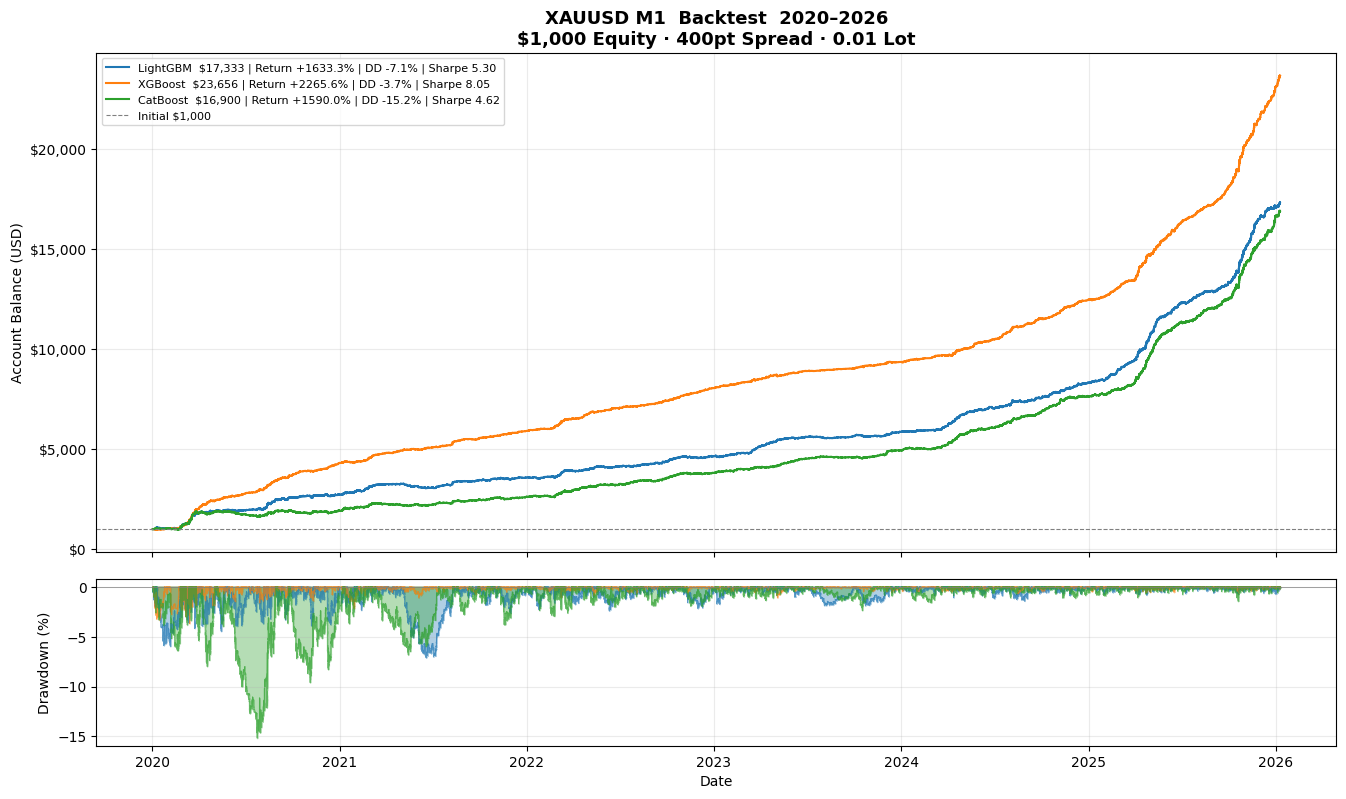

,entry_dt,exit_dt,direction,entry_price,close_price,pnl_usd,close_reason,bars_held
0,2020-01-01 19:45:00,2020-01-01 20:04:00,Sell,1518.58,1518.07,0.11,Time,5
1,2020-01-01 20:06:00,2020-01-01 20:20:00,Buy,1518.08,1520.54,2.05,Time,5
2,2020-01-01 20:28:00,2020-01-01 20:37:00,Sell,1520.11,1519.73,-0.02,Time,5
3,2020-01-01 20:57:00,2020-01-01 21:21:00,Sell,1519.77,1519.53,-0.16,Time,5
4,2020-01-02 02:00:00,2020-01-02 02:28:00,Buy,1520.59,1519.44,-1.56,Time,5


In [ ]:
# ─── Contoh pemanggilan ───────────────────────────────────────────────────────
# Ganti dengan variabel yang sudah ada di notebook Anda:

results = run_all_backtests(
    models_to_test = models_to_test,
    alpha_df       = alpha_df,
    alpha_features = alpha_features,
    initial_equity = 1_000,
    hold_bars      = 5,
    sl_points      = 4000,   # contoh: 500 point SL
    tp_points      = 8000,   # contoh: 1000 point TP
)

# Akses trade log model pertama:
results[0]["trade_df"].head()

In [ ]:
len(X_train)

1199896

In [ ]:
!pip install -q onnxmltools onnxconverter-common skl2onnx onnxruntime

import onnxmltools
from onnxmltools.convert.common.data_types import FloatTensorType
import os

# Prepare Models
print("Re-fitting models for ONNX conversion...")

# 1. Convert LightGBM
lgb_model = get_new_model('LightGBM', results_tuned[0]['Best_Params'])
lgb_model.fit(X_train, y_train)
print("Converting LightGBM to ONNX...")
initial_type = [('float_input', FloatTensorType([None, len(alpha_features)]))]
onnx_lgb = onnxmltools.convert_lightgbm(lgb_model, initial_types=initial_type, target_opset=12)
onnxmltools.utils.save_model(onnx_lgb, 'xauusd_lgb.onnx')

# 2. Convert XGBoost
xgb_model = get_new_model('XGBoost', results_tuned[1]['Best_Params'])
# Fix for XGBoost feature naming requirement in ONNX
renamed_features = [f'f{i}' for i in range(len(alpha_features))]
xgb_model.fit(X_train.values, y_train.values)
xgb_model.get_booster().feature_names = renamed_features

print("Converting XGBoost to ONNX...")
onnx_xgb = onnxmltools.convert_xgboost(xgb_model, initial_types=initial_type, target_opset=12)
onnxmltools.utils.save_model(onnx_xgb, 'xauusd_xgb.onnx')

# 3. Convert CatBoost
cat_model = get_new_model('CatBoost', results_tuned[2]['Best_Params'])
cat_model.fit(X_train, y_train)
print("Converting CatBoost to ONNX...")
cat_model.save_model(
    "xauusd_catboost.onnx",
    format="onnx",
    export_parameters={
        'onnx_domain': 'ai.catboost',
        'onnx_model_version': 1,
        'onnx_doc_string': 'XAUUSD CatBoost Alpha Model'
    }
)

print("\nDone! Models saved:")
!ls -lh *.onnx

Re-fitting models for ONNX conversion...
Converting LightGBM to ONNX...
Converting XGBoost to ONNX...
Converting CatBoost to ONNX...

Done! Models saved:
-rw-r--r-- 1 root root 154K Mar 24 16:35 xauusd_catboost.onnx
-rw-r--r-- 1 root root 670K Mar 24 16:33 xauusd_lgb.onnx
-rw-r--r-- 1 root root 291K Mar 24 16:33 xauusd_xgb.onnx


In [ ]:
feature_list = [
    ('0. Open', 'Harga Open bar saat ini'),
    ('1. Volume', 'Tick Volume (bisa diisi 0 jika tidak tersedia)'),
    ('2. body_size', 'abs(Close - Open)'),
    ('3. range', 'High - Low'),
    ('4. log_ret', 'log(Close / Close[1])'),
    ('5. kama_10', 'Kaufman Adaptive Moving Average (Window 10)'),
    ('6. rsi_14', 'Relative Strength Index (Window 14)'),
    ('7. ema_dist_9', '(Close - EMA_9) / EMA_9'),
    ('8. ema_slope_9', 'EMA_9[0] - EMA_9[5]'),
    ('9. rsi_7', 'Relative Strength Index (Window 7)'),
    ('10. rsi_accel_7', 'rsi_7[0] - rsi_7[3]'),
    ('11. rsi_accel_14', 'rsi_14[0] - rsi_14[3]'),
    ('12. rsi_21', 'Relative Strength Index (Window 21)'),
    ('13. rsi_accel_21', 'rsi_21[0] - rsi_21[3]'),
    ('14. parkinson_vol', 'sqrt(1/(4*log(2)) * log(High/Low)^2) moving average 30'),
    ('15. wick_ratio', '(High - max(Open, Close)) / (High - Low + 1e-9)'),
    ('16. body_pct', 'abs(Open - Close) / (High - Low + 1e-9)'),
    ('17. fvg', 'Fair Value Gap: 1 (L[+1]>H[-1]), -1 (H[+1]<L[-1]), else 0'),
    ('18. rolling_skew', 'Skewness dari log_ret (Window 100)'),
    ('19. rolling_kurt', 'Kurtosis dari log_ret (Window 100)'),
    ('20. zscore_30', '(Close - mean_30) / std_30'),
    ('21. hour', 'Jam server MT5 (0-23)'),
    ('22. is_london', '1 jika hour antara 7-15, else 0'),
    ('23. is_ny', '1 jika hour antara 12-20, else 0')
]

content = []
content.append('# Panduan Integrasi ONNX XAUUSD (M1)')
content.append('\n## 1. Daftar Fitur Lengkap (Total: 24)')
content.append('Urutan ini harus sama persis di array `float input_data[24]` pada MQL5:')
for feat, desc in feature_list:
    content.append(f'- **{feat}**: {desc}')

content.append('\n## 2. Contoh Kode MQL5 Expert Advisor')
content.append('```cpp')
content.append('#resource "\\\\Files\\\\xauusd_lgb.onnx" as uchar onnx_data[]')
content.append('long model_handle = INVALID_HANDLE;')
content.append('int OnInit() {')
content.append('    model_handle = OnnxCreateFromBuffer(onnx_data, ONNX_DEFAULT);')
content.append('    long input_shape[] = {1, 24};')
content.append('    OnnxSetInputShape(model_handle, 0, input_shape);')
content.append('    return(INIT_SUCCEEDED);')
content.append('}')
content.append('void OnTick() {')
content.append('    float input_data[24];')
content.append('    // Isi sesuai urutan di atas...')
content.append('    // input_data[0] = (float)iOpen(_Symbol, _Period, 0);')
content.append('    // input_data[21] = (float)TimeHour(TimeCurrent());')
content.append('    long output_data[1];')
content.append('    long output_shape[] = {1};')
content.append('    OnnxSetOutputShape(model_handle, 0, output_shape);')
content.append('    if(OnnxRun(model_handle, ONNX_DEBUG_LOGS, input_data, output_data)) {')
content.append('        int signal = (int)output_data[0] - 1; // -1: Sell, 0: Flat, 1: Buy')
content.append('        Print("Signal Dihasilkan: ", signal);')
content.append('    }')
content.append('}')
content.append('void OnDeinit(const int reason) { OnnxRelease(model_handle); }')
content.append('```')

with open('Panduan_MQL5_ONNX.md', 'w') as f:
    f.write('\n'.join(content))

print("File Panduan_MQL5_ONNX.md telah diperbarui dengan daftar fitur lengkap.")

File Panduan_MQL5_ONNX.md telah diperbarui dengan daftar fitur lengkap.
